# Drawing Areas of Interest

```{note}
This notebook requires files in the `docs/assets` folder. If you want to run it on your local machine, the easiest way is to [download the entire repository](https://github.com/HanZhang-psych/pupeyes/tree/main). 
```

```{admonition} Overview
This tutorial will introduce an AOI drawing tool, `AOIDrawer`, and showcase some basic AOI-based analyses you can do with PupEyes.
```

## The AOI Drawer

PupEyes includes an `AOIDrawer` that allows you to manually define AOIs. The defined AOIs will be saved as a `.json` file and can be used in other PupEyes functions.

In [10]:
from pupeyes import AOIDrawer

# path to image
background_img = 'assets/street1.jpg'

# Create and run the drawer
drawer = AOIDrawer(screen_dims=(1600, 1200), stimuli=background_img, stimuli_name='street1')

# Comment out when running locally
# drawer.run()

```{image} assets/aoi_drawer.gif
:name: aoi_drawer
```

The saved AOIs can be reloaded and used in other PupEyes functions. For example, let's load the saved AOIs and redraw them.

In [2]:
import json

# load AOIs
with open('assets/street1_aois.json', 'r') as f:
    aois = json.load(f)

`aois` is a Python dictionary that stores the vertices of each AOI. The last point repeats the first point to close the polygon.

In [3]:
print('lights', aois['lights'])

lights [[229.32328532512912, 178.23073308270676], [357.8947138965577, 178.23073308270676], [357.8947138965577, 349.65930451127815], [229.32328532512912, 349.65930451127815], [229.32328532512912, 178.23073308270676]]


Let's draw these AOIs using `draw_aois()` from PupEyes 

Original size: (6231, 4154) Resized size: (1600, 1200)


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Areas of Interest (AOIs)'}>)

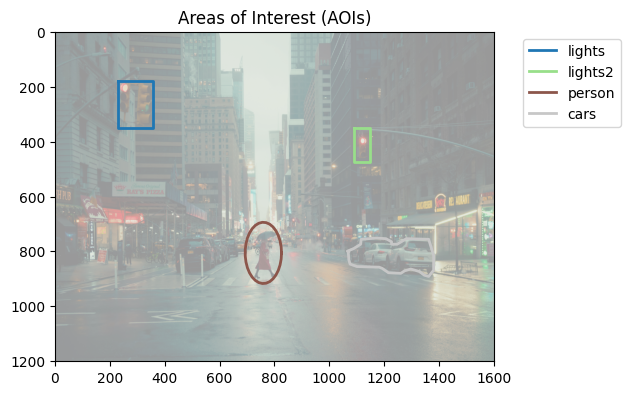

In [4]:
from pupeyes import draw_aois

# draw AOI
draw_aois(aois, screen_dims=(1600, 1200), background_img=background_img)

### Calculating Basic AOI Measures

To illustrate how the defined AOIs can be used in subsequent analyses, we will do some simple AOI-based analysis: we will assign each fixation to an AOI and compute some basic AOI measures.

In [5]:
import numpy as np
import pandas as pd

# generate some fake data
fixations = np.array([
    (50, 50, 200), # None
    (300, 250, 300), # lights
    (500, 250, 100), # None
    (750, 800, 350), # person
    (750, 800, 250), # person
    (750, 600, 100), # None
    (1100, 800, 450), # cars
    (1100, 400, 150), # lights2
    (1500, 400, 1000)] # None
                    )
fixation_data = pd.DataFrame(fixations, columns=['x','y','duration'])
fixation_data['correct_aoi'] = [None, 'lights', None, 'person', 'person', None, 'cars', 'lights2', None]
fixation_data

,x,y,duration,correct_aoi
0,50,50,200,None
1,300,250,300,lights
2,500,250,100,None
3,750,800,350,person
4,750,800,250,person
5,750,600,100,None
6,1100,800,450,cars
7,1100,400,150,lights2
8,1500,400,1000,None


In [6]:
from pupeyes.aoi import get_fixation_aoi, compute_aoi_statistics

# get the corresponding AOI for each fixation
fixation_data['aoi'] = get_fixation_aoi(x=fixations[:, 0], # x pos
                                        y=fixations[:, 1], # y pos
                                        aois=aois)
# assigned aois match the correct aois
fixation_data

,x,y,duration,correct_aoi,aoi
0,50,50,200,None,None
1,300,250,300,lights,lights
2,500,250,100,None,None
3,750,800,350,person,person
4,750,800,250,person,person
5,750,600,100,None,None
6,1100,800,450,cars,cars
7,1100,400,150,lights2,lights2
8,1500,400,1000,None,None


`compute_aoi_statistics()` allows you to compute basic AOI-based measures, given the x and y coordinates, AOIs, and fixation durations.

In [7]:
results = compute_aoi_statistics(
    x=fixation_data['x'],
    y=fixation_data['y'],
    aois=aois,
    durations=fixation_data['duration']
)

pd.DataFrame(results)

,outside,lights,lights2,person,cars
count,4.0,1.0,1.0,2.0,1.0
total_duration,1400.0,300.0,150.0,600.0,450.0


```{tip}
You can supply your own AOIs to `draw_aoi()`, `get_fixation_aoi()`, and `compute_aoi_statistics()`.
```